## Treta Laboratoriska vezba


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [ ]:
df = pd.read_excel("Data_Cortex_Nuclear.xls")  


df.head()
df.info()
df.describe()


X = df.iloc[:, 1:-4]   


X = X.dropna()   


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   str    
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N          1077 non

## 2D PCA

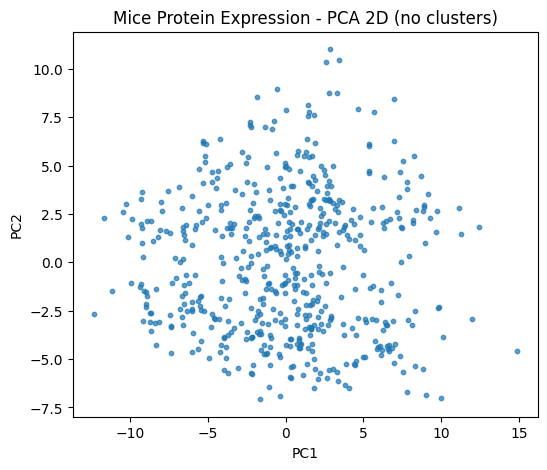

In [15]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=10, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Mice Protein Expression - PCA 2D (no clusters)")
plt.show()

## 3D PCA


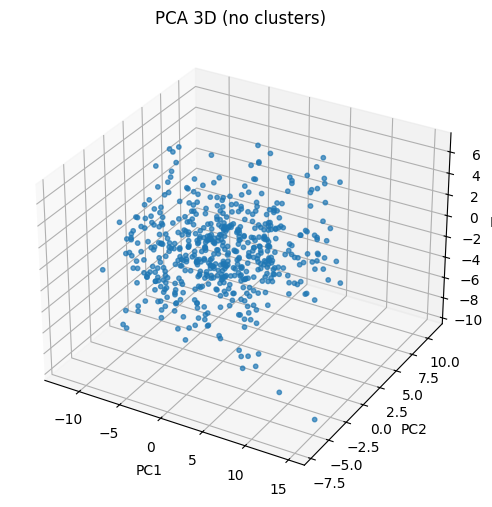

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], s=10, alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D (no clusters)")
plt.show()

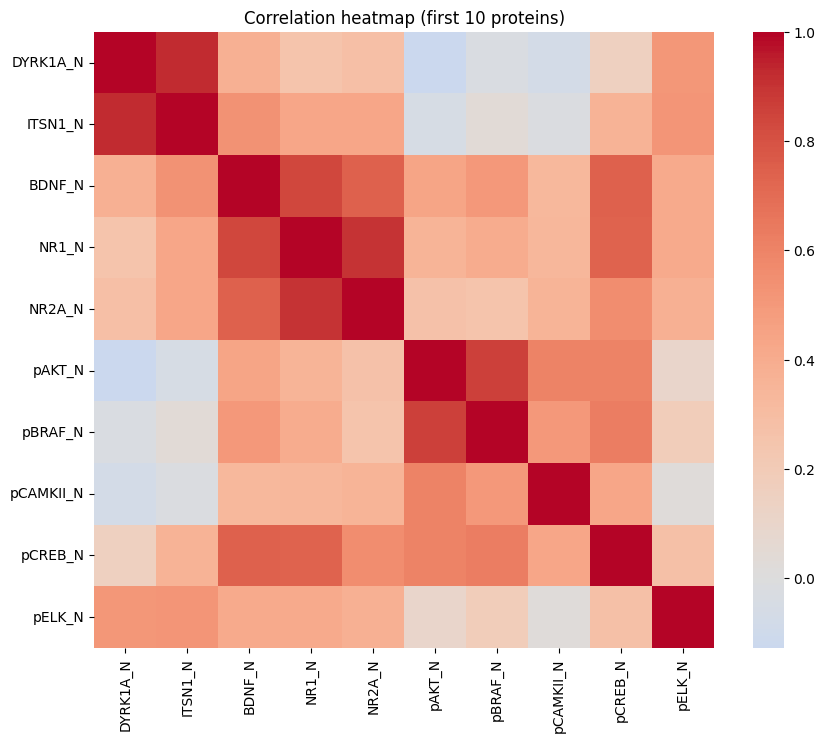

In [23]:
feature_cols = df.columns[1:-4]
plt.figure(figsize=(10, 8))
corr = pd.DataFrame(X_scaled, columns=feature_cols).iloc[:, :10].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (first 10 proteins)")
plt.show()

## K-Means clustering

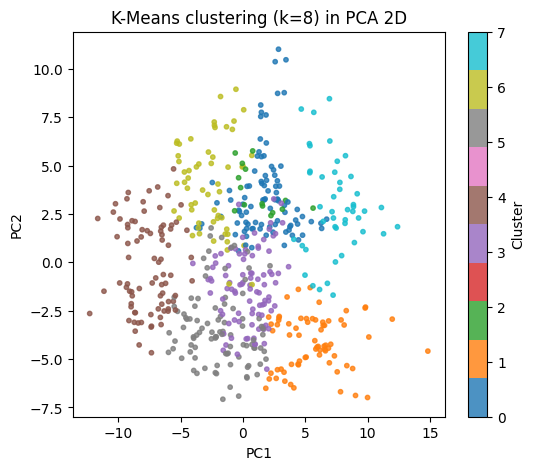

In [34]:

k = 8

kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)


plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=kmeans_labels, cmap="tab10", s=10, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means clustering (k={k}) in PCA 2D")
plt.colorbar(scatter, label="Cluster")
plt.show()

## GMM clustering


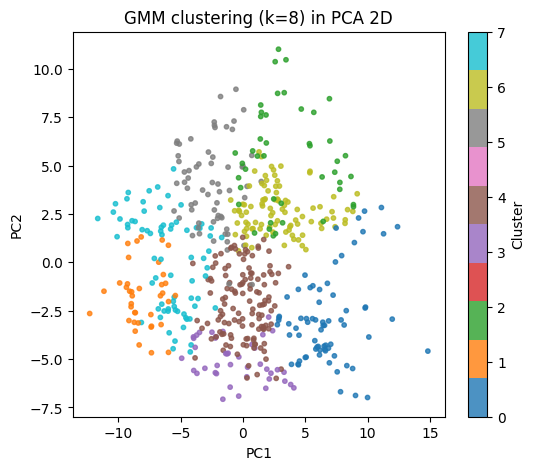

In [35]:
# 4.1 Fit Gaussian Mixture with same number of components
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
gmm_labels = gmm.fit_predict(X_scaled)

# 4.2 Visualize in PCA 2D
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=gmm_labels, cmap="tab10", s=10, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM clustering (k={k}) in PCA 2D")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Sporedba

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# (повеќе е подобро)
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_gmm = silhouette_score(X_scaled, gmm_labels)

# (повеќе е подобро)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)
ch_gmm = calinski_harabasz_score(X_scaled, gmm_labels)

# - помалку е подобро
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
db_gmm = davies_bouldin_score(X_scaled, gmm_labels)

print("K-Means:   Silhouette =", sil_kmeans,
      " CH =", ch_kmeans, " DB =", db_kmeans)
print("GMM:       Silhouette =", sil_gmm,
      " CH =", ch_gmm, " DB =", db_gmm)

K-Means:   Silhouette = 0.1611398982538076  CH = 70.86714226680164  DB = 1.7842327394306117
GMM:       Silhouette = 0.1479802915009141  CH = 67.81192380432526  DB = 1.8853123039462978


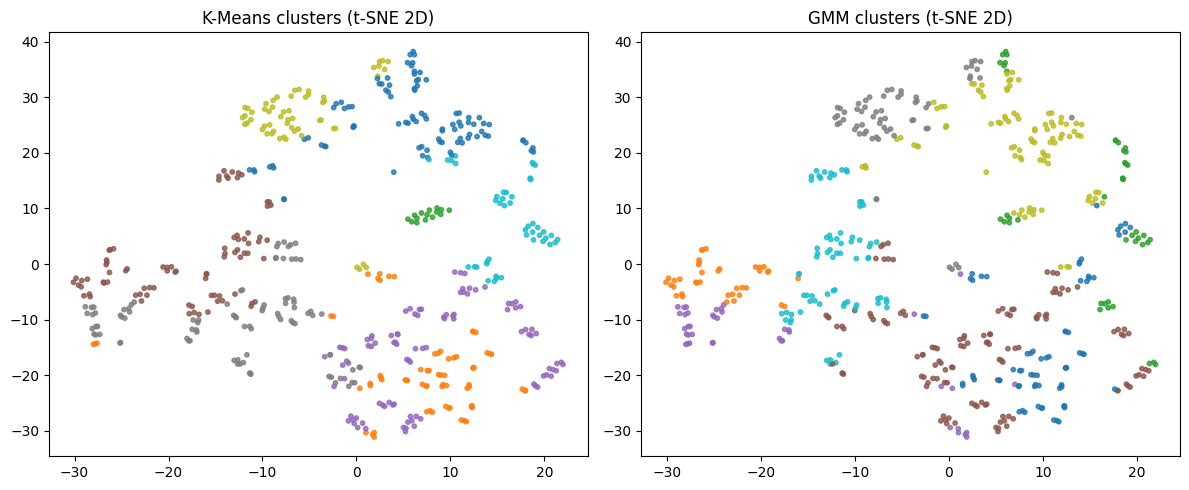

In [37]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=kmeans_labels, cmap="tab10", s=10, alpha=0.8)
axes[0].set_title("K-Means clusters (t-SNE 2D)")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=gmm_labels, cmap="tab10", s=10, alpha=0.8)
axes[1].set_title("GMM clusters (t-SNE 2D)")

plt.tight_layout()
plt.show()